In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('heart.csv')

In [3]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


# EDA

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


In [5]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


[Text(0, 0, '508'), Text(0, 0, '410')]

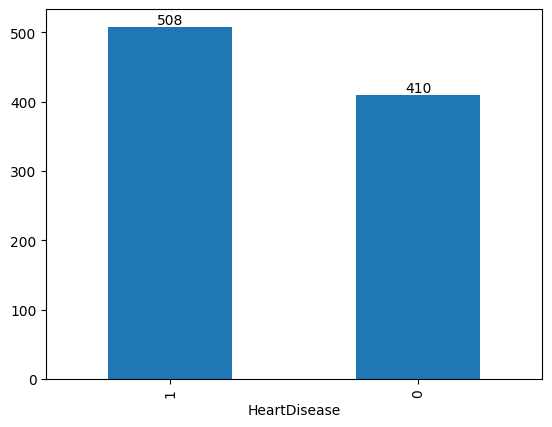

In [6]:
ax = df['HeartDisease'].value_counts().plot(kind='bar')
ax.bar_label(ax.containers[0])

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

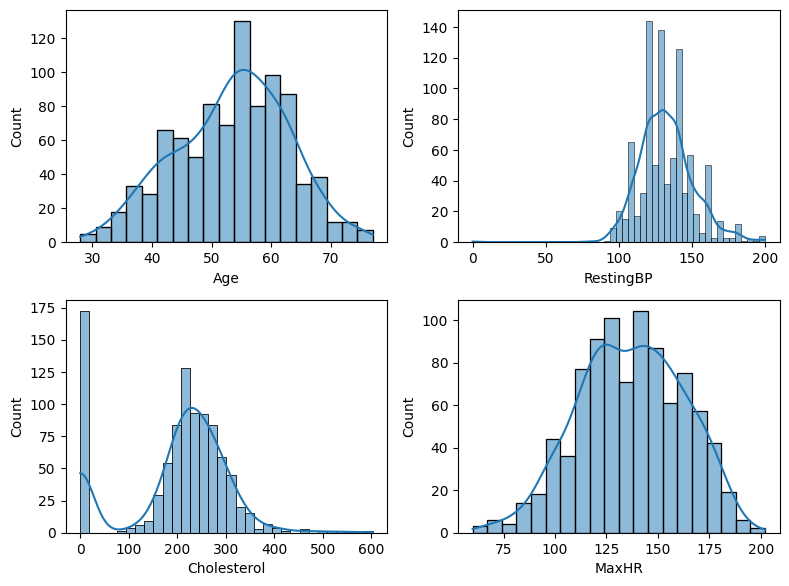

In [9]:
plt.figure(figsize=(8, 6))

def ploting(col, n):
    plt.subplot(2, 2, n)
    sns.histplot(df[col], kde= True)

ploting('Age', 1)
ploting('RestingBP', 2)
ploting('Cholesterol', 3)
ploting('MaxHR', 4)

plt.tight_layout()


In [10]:
mean_bp = df[df['RestingBP'] != 0]['RestingBP'].mean()

In [11]:
mean_col = df[df['Cholesterol'] != 0]['Cholesterol'].mean()

In [12]:
df['RestingBP'] = df['RestingBP'].replace(0, mean_bp)

In [13]:
df['Cholesterol'] = df['Cholesterol'].replace(0, mean_col)

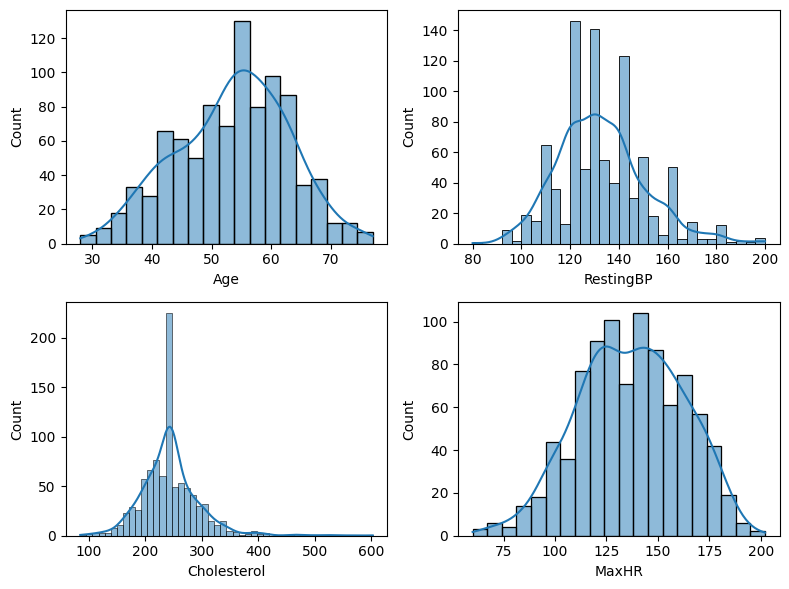

In [14]:
plt.figure(figsize=(8, 6))

def ploting(col, n):
    plt.subplot(2, 2, n)
    sns.histplot(df[col], kde= True)

ploting('Age', 1)
ploting('RestingBP', 2)
ploting('Cholesterol', 3)
ploting('MaxHR', 4)

plt.tight_layout()

In [15]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

[Text(0, 0, '458'), Text(0, 0, '50')]

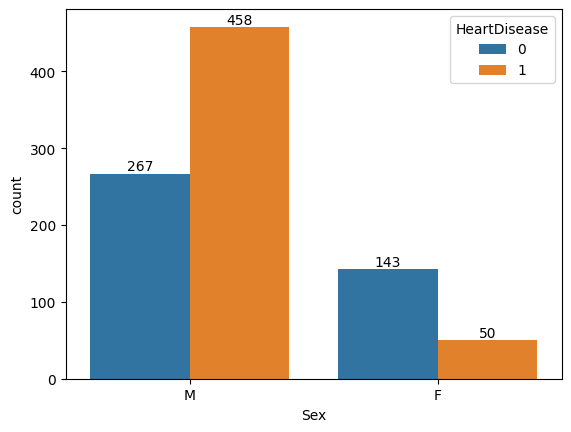

In [16]:
ax = sns.countplot(x = df['Sex'], hue = df['HeartDisease'])
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

[Text(0, 0, '24'), Text(0, 0, '72'), Text(0, 0, '392'), Text(0, 0, '20')]

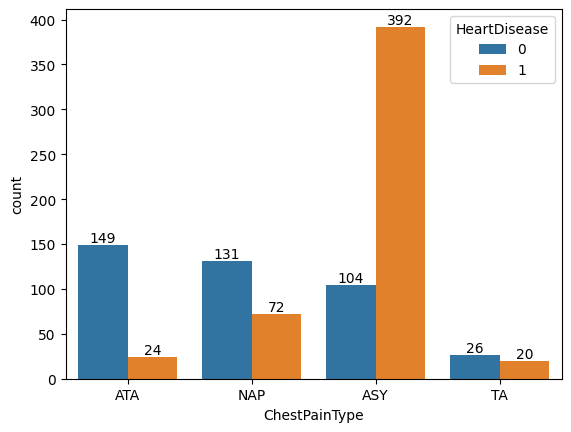

In [17]:
ax = sns.countplot(x = df['ChestPainType'], hue = df['HeartDisease'])
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

[Text(0, 0, '192'), Text(0, 0, '316')]

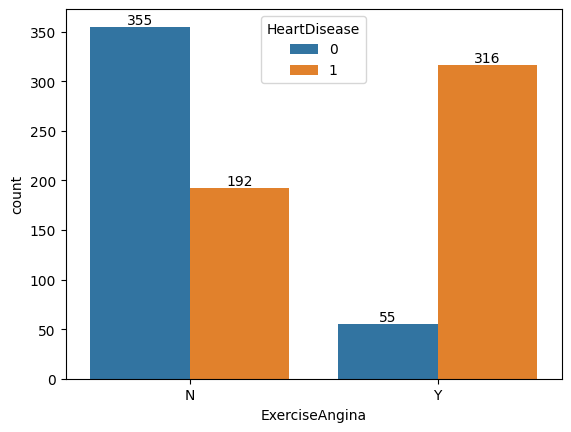

In [18]:
ax = sns.countplot(x = df['ExerciseAngina'], hue = df['HeartDisease'])
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

[Text(0, 0, '78'), Text(0, 0, '381'), Text(0, 0, '49')]

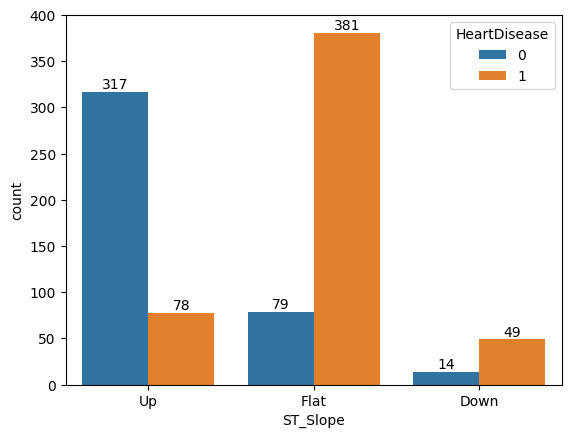

In [20]:
ax = sns.countplot(x = df['ST_Slope'], hue = df['HeartDisease'])
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

<Axes: xlabel='Oldpeak', ylabel='Count'>

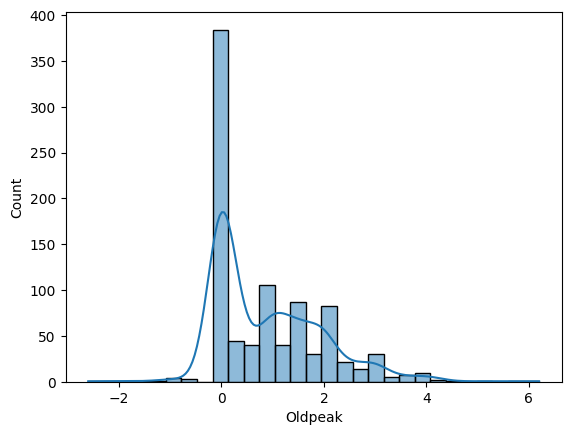

In [ ]:
sns.histplot(x = df['Oldpeak'], kde = True)

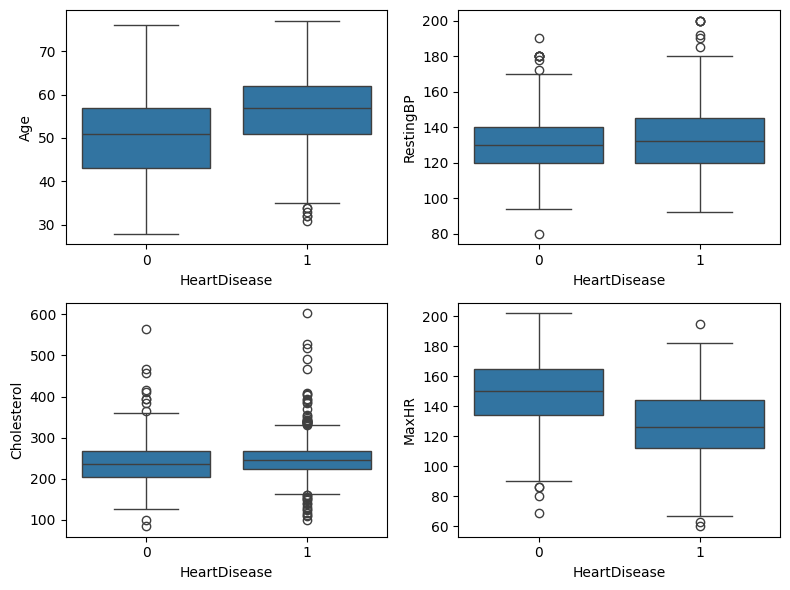

In [ ]:
plt.figure(figsize=(8, 6))
def ploting(col, n):
    plt.subplot(2, 2, n)
    sns.boxplot(x = df['HeartDisease'], y = df[col])

ploting('Age', 1)
ploting('RestingBP', 2)
ploting('Cholesterol', 3)
ploting('MaxHR', 4)

plt.tight_layout()

<Axes: >

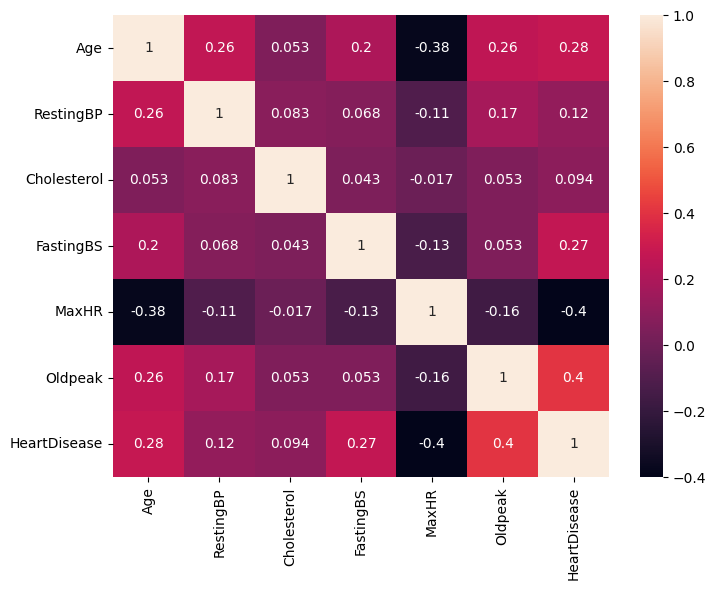

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True)

# Data Preprocessing 

In [ ]:
df_encode = pd.get_dummies(df)

In [ ]:
df_encode = df_encode.drop(columns = ['Sex_F'])

In [ ]:
df_encode = df_encode.astype('int')

<Axes: xlabel='Cholesterol', ylabel='Count'>

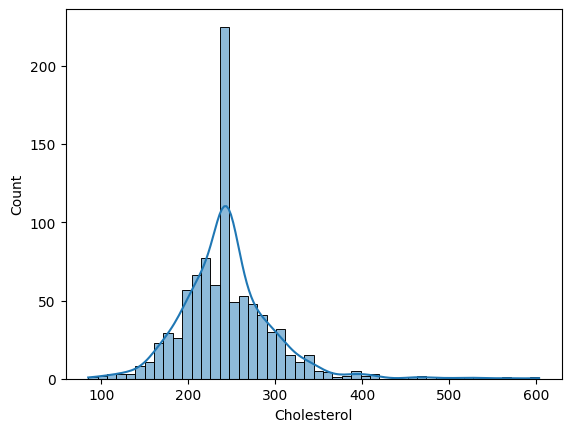

In [ ]:
sns.histplot(df_encode['Cholesterol'], kde = True)

In [ ]:
df_encode.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA',
       'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH',
       'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N',
       'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='str')

In [ ]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,0,1,0,0,0,1,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,0,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,0,1,0,0,0,0,1,1,0,0,0,1
3,48,138,214,0,108,1,1,0,1,0,0,0,0,1,0,0,1,0,1,0
4,54,150,195,0,122,0,0,1,0,0,1,0,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,1,0,0,0,1,0,1,0,1,0,0,1,0
914,68,144,193,1,141,3,1,1,1,0,0,0,0,1,0,1,0,0,1,0
915,57,130,131,0,115,1,1,1,1,0,0,0,0,1,0,0,1,0,1,0
916,57,130,236,0,174,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0


# Model Implementation

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
x = df_encode.drop(columns = ['HeartDisease'])
y = df['HeartDisease']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, random_state = 42)

#### Some Model like DecissionTree work better wittout Standerd Scalling

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

In [ ]:
models = {
    "Logistic Regression" : LogisticRegression(), 
    "KNN" : KNeighborsClassifier(), 
    "Naive Biyas" : GaussianNB(), 
    "Decision Tree" : DecisionTreeClassifier(), 
    "SVC" : SVC()
}

result = []

In [ ]:
for name, model in models.items() :
    model.fit(x_train_scaled, y_train)
    y_pred = model.predict(x_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    result.append({
        "Model" : name, 
        "Accuracy" : round(acc, 2), 
        "F1 Score" : round(f1, 2), 
    })

In [ ]:
result

[{'Model': 'Logistic Regression', 'Accuracy': 0.88, 'F1 Score': 0.89},
 {'Model': 'KNN', 'Accuracy': 0.86, 'F1 Score': 0.88},
 {'Model': 'Naive Biyas', 'Accuracy': 0.84, 'F1 Score': 0.85},
 {'Model': 'Decision Tree', 'Accuracy': 0.8, 'F1 Score': 0.81},
 {'Model': 'SVC', 'Accuracy': 0.86, 'F1 Score': 0.88}]

In [ ]:
import joblib

joblib.dump(models['Logistic Regression'], 'LR_heart.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(x.columns.tolist(), 'columns.pkl')

['columns.pkl']